# Model Training & Evaluation - Pre-Send Features Only

**Input:** `unsw_cleaned_features.csv` (2,059,414 rows x 42 columns).

`03_data_visualization_and_model_selection.ipynb` picked **Random Forest and XGBoost** as the model family from the data's general shape (skew, outliers, non-linear separability), and separately narrowed the 16 pre-send candidates down to a final 10-column `X` with evidence for each exclusion (Section 10 there): `swin`, `proto`, `service` leak TCP-vs-not identity (this dataset's loss counters are only measurable on TCP traffic); `Spkts` and `sbytes` are real but so dominant individually that they make the problem trivially easy; `sttl` simply wasn't part of the chosen combination (confirmed not dangerous on its own).

This notebook trains **4 candidates** - Logistic Regression, Decision Tree, Random Forest, XGBoost - on a proper **60% train / 20% validation / 20% test** split, and reports **confusion matrix, precision, recall, and F1** for every one of them (not just accuracy - with a 70/30 class balance, accuracy alone would be a weak signal).

**Feature set (10 columns, locked in from the previous notebook):**
```python
final_feature_cols = [
    'smeansz', 'dst_port_bucket',
    'ct_state_ttl', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm',
    'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
]
```

**Model configuration:**

| Model | Configuration |
|---|---|
| Logistic Regression | defaults, `class_weight='balanced'` |
| Decision Tree | `max_depth=3` |
| Random Forest | `n_estimators=200`, `max_depth=5` |
| XGBoost | `n_estimators=10`, `max_depth=2`, `learning_rate=0.31` |

## Contents

1. Feature / target setup
2. Train / validation / test split (60/20/20, stratified)
3. Encode categorical features
4. Train all 4 models
5. Confusion matrices - all 4 models, validation set
6. Precision / recall / F1 - all 4 models, validation set
7. Final check on the held-out test set
8. Conclusion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_PATH = 'unsw_cleaned_features.csv'
df = pd.read_csv(DATA_PATH, low_memory=False)
print('Shape:', df.shape)

Shape: (2059414, 42)


## Section 1 - Feature / target setup

In [2]:
candidate_categorical = ['dst_port_bucket']
candidate_numeric = [
    'smeansz',
    'ct_state_ttl', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm',
    'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
]

X = df[candidate_numeric + candidate_categorical]
y = df['packet_lost']

print(f"Features: {len(candidate_numeric)} numeric + {len(candidate_categorical)} categorical = {X.shape[1]} total")
print(f"Target positive rate: {y.mean()*100:.2f}%")

Features: 9 numeric + 1 categorical = 10 total
Target positive rate: 70.31%


## Section 2 - Train / validation / test split (60/20/20, stratified)

Done in two steps: first carve off the 20% test set, then split the remaining 80% into 60% train / 20% validation (25% of the remaining 80%). Stratifying on `packet_lost` at each step keeps the same ~70% positive rate in all three sets.

In [3]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)

print(f"Train shape: {X_train.shape}  ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val shape  : {X_val.shape}  ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test shape : {X_test.shape}  ({len(X_test)/len(X)*100:.1f}%)")
print()
print(f"Train positive rate: {y_train.mean()*100:.2f}%")
print(f"Val positive rate  : {y_val.mean()*100:.2f}%")
print(f"Test positive rate : {y_test.mean()*100:.2f}%")

Train shape: (1235648, 10)  (60.0%)
Val shape  : (411883, 10)  (20.0%)
Test shape : (411883, 10)  (20.0%)

Train positive rate: 70.31%
Val positive rate  : 70.31%
Test positive rate : 70.31%


## Section 3 - Encode categorical features

Numeric columns pass through unchanged; `service` and `dst_port_bucket` get one-hot encoded. The encoder is fit on the training set only, then just applied (`transform`) to validation and test, so no information leaks across the splits.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer([
    ('num', 'passthrough', candidate_numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore'), candidate_categorical),
])

X_train_enc = preprocessor.fit_transform(X_train)
X_val_enc = preprocessor.transform(X_val)
X_test_enc = preprocessor.transform(X_test)

print('Encoded train shape:', X_train_enc.shape)
print('Encoded val shape  :', X_val_enc.shape)
print('Encoded test shape :', X_test_enc.shape)

Encoded train shape: (1235648, 14)
Encoded val shape  : (411883, 14)
Encoded test shape : (411883, 14)


## Section 4 - Train all 4 models

Same 4 candidates as the earlier visualization notebook's discussion: Logistic Regression (reference baseline), Decision Tree, Random Forest, XGBoost. All use `class_weight='balanced'` / `scale_pos_weight` so the 70/30 imbalance is accounted for rather than ignored.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', max_depth=3, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=5, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=10, max_depth=2, learning_rate=0.31, scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42),
}

for name, model in models.items():
    model.fit(X_train_enc, y_train)
    print(f"Trained: {name}")

## Section 5 - Confusion matrices - all 4 models, validation set

Model selection happens on the validation set, not the test set - test stays untouched until Section 7, the final unbiased check.

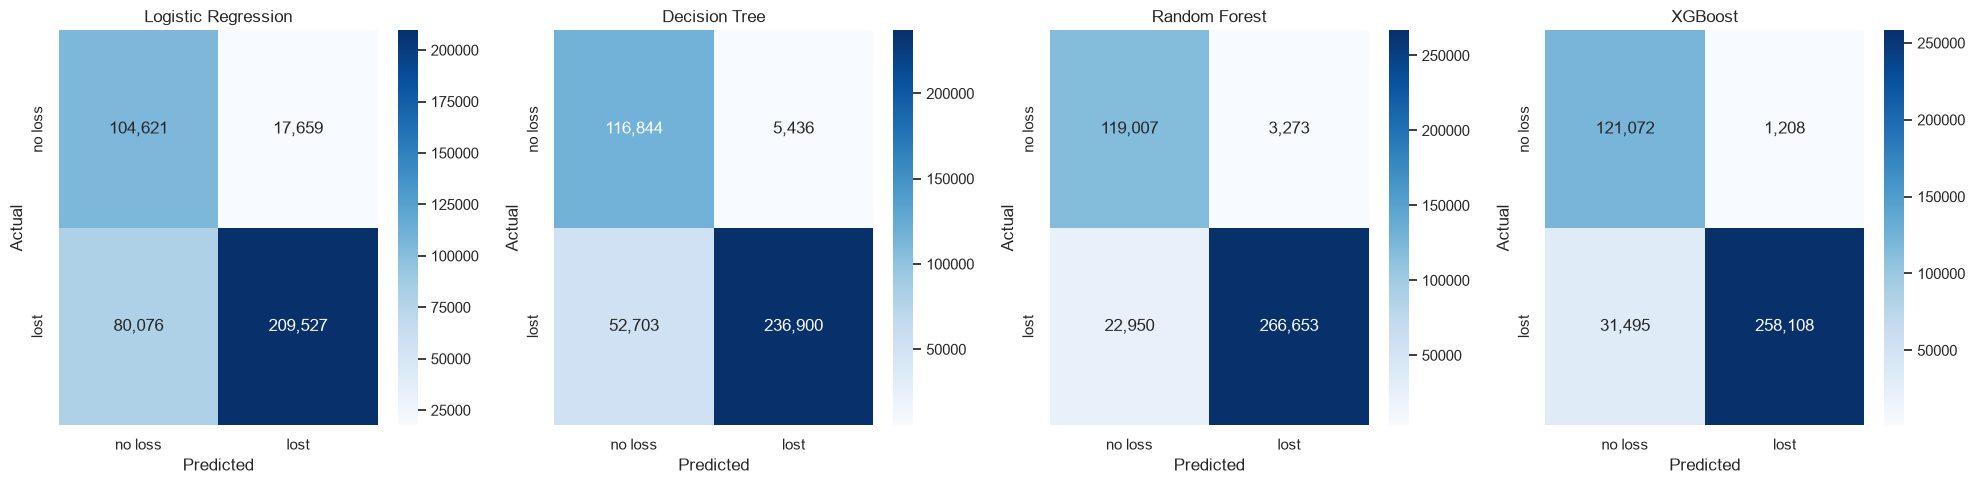

In [6]:
from sklearn.metrics import confusion_matrix

val_preds = {name: model.predict(X_val_enc) for name, model in models.items()}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, preds) in zip(axes, val_preds.items()):
    cm = confusion_matrix(y_val, preds)
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
                xticklabels=['no loss', 'lost'], yticklabels=['no loss', 'lost'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Section 6 - Precision / recall / F1 - all 4 models, validation set

Reported per class (0 = no loss, 1 = lost) plus macro average, so both classes' performance is visible - not just the majority class.

In [7]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

rows = []
for name, preds in val_preds.items():
    precision, recall, f1, _ = precision_recall_fscore_support(y_val, preds, labels=[0, 1], zero_division=0)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(y_val, preds, average='macro', zero_division=0)
    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_val, preds),
        'Precision (0=no loss)': precision[0], 'Recall (0=no loss)': recall[0], 'F1 (0=no loss)': f1[0],
        'Precision (1=lost)': precision[1], 'Recall (1=lost)': recall[1], 'F1 (1=lost)': f1[1],
        'Macro F1': macro_f1,
    })

val_metrics_df = pd.DataFrame(rows).set_index('Model').round(4)
val_metrics_df

,Accuracy,Precision (0=no loss),Recall (0=no loss),F1 (0=no loss),Precision (1=lost),Recall (1=lost),F1 (1=lost),Macro F1
Model,,,,,,,,
Logistic Regression,0.7627,0.5664,0.8556,0.6816,0.9223,0.7235,0.8109,0.7463
Decision Tree,0.8588,0.6892,0.9555,0.8008,0.9776,0.8180,0.8907,0.8457
Random Forest,0.9363,0.8383,0.9732,0.9008,0.9879,0.9208,0.9531,0.9269
XGBoost,0.9206,0.7936,0.9901,0.8810,0.9953,0.8912,0.9404,0.9107


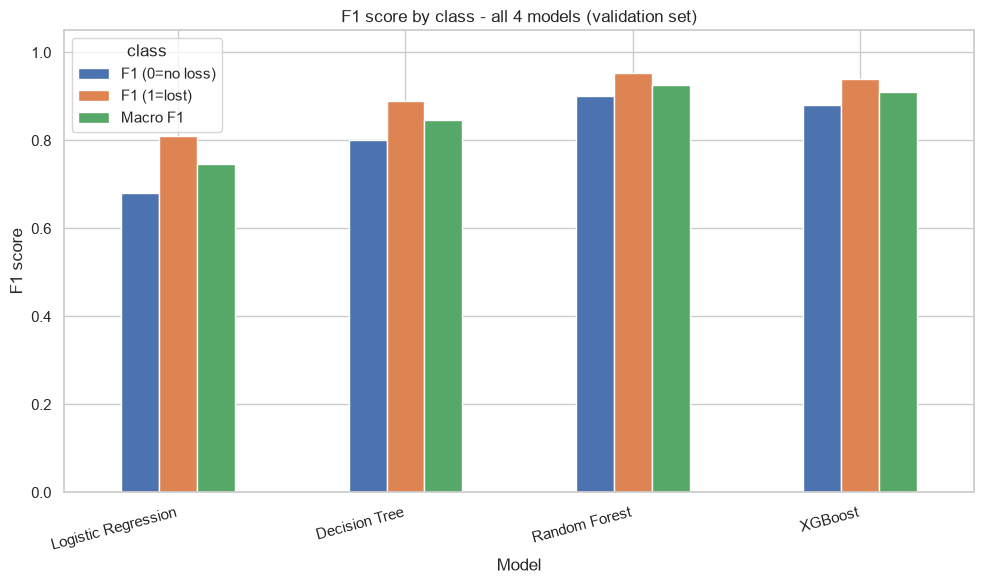

In [8]:
val_metrics_df[['F1 (0=no loss)', 'F1 (1=lost)', 'Macro F1']].plot(kind='bar', figsize=(10, 6))
plt.ylabel('F1 score')
plt.title('F1 score by class - all 4 models (validation set)')
plt.ylim(0, 1.05)
plt.xticks(rotation=15, ha='right')
plt.legend(title='class')
plt.tight_layout()
plt.show()

## Section 7 - Final check on the held-out test set

The test set has not been touched until now. Same confusion matrices and precision/recall/F1 table, computed once, to confirm the validation results generalize rather than being an artifact of that particular split.

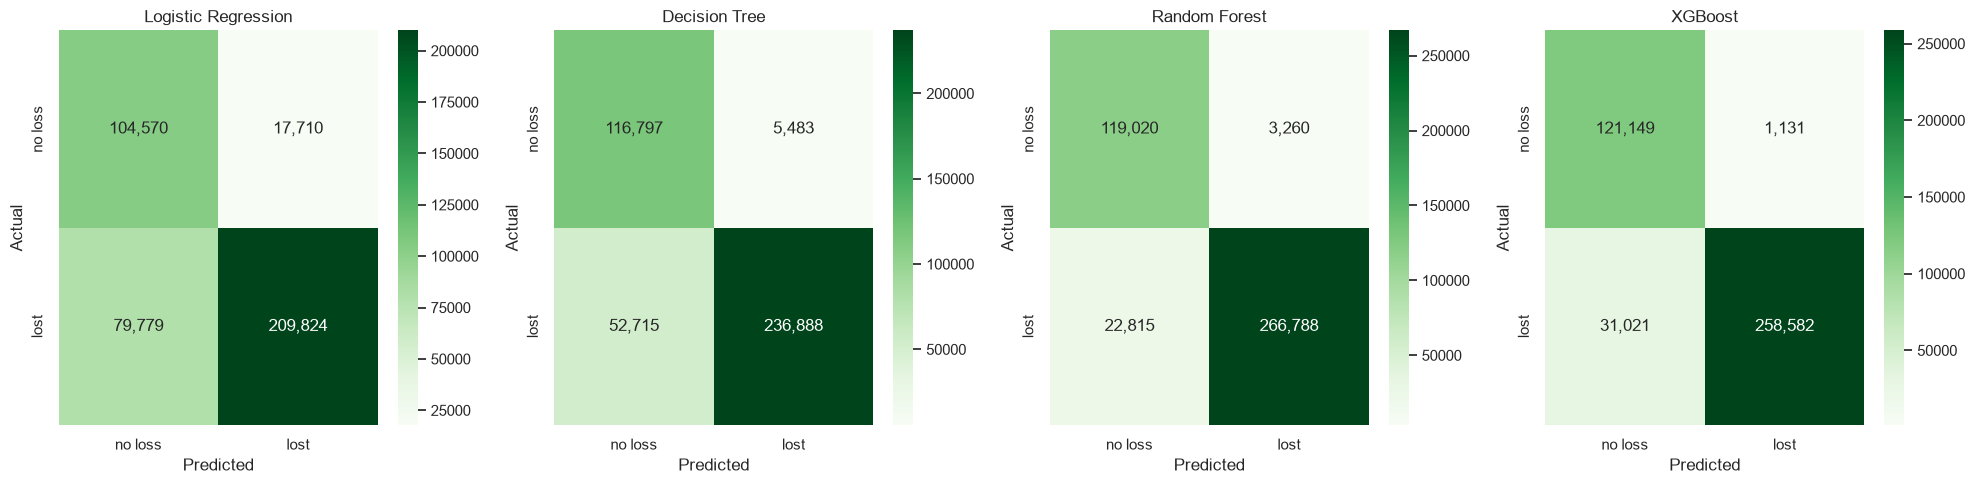

In [9]:
test_preds = {name: model.predict(X_test_enc) for name, model in models.items()}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, preds) in zip(axes, test_preds.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Greens', ax=ax,
                xticklabels=['no loss', 'lost'], yticklabels=['no loss', 'lost'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [10]:
rows = []
for name, preds in test_preds.items():
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, preds, labels=[0, 1], zero_division=0)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(y_test, preds, average='macro', zero_division=0)
    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision (0=no loss)': precision[0], 'Recall (0=no loss)': recall[0], 'F1 (0=no loss)': f1[0],
        'Precision (1=lost)': precision[1], 'Recall (1=lost)': recall[1], 'F1 (1=lost)': f1[1],
        'Macro F1': macro_f1,
    })

test_metrics_df = pd.DataFrame(rows).set_index('Model').round(4)
test_metrics_df

,Accuracy,Precision (0=no loss),Recall (0=no loss),F1 (0=no loss),Precision (1=lost),Recall (1=lost),F1 (1=lost),Macro F1
Model,,,,,,,,
Logistic Regression,0.7633,0.5672,0.8552,0.6821,0.9222,0.7245,0.8115,0.7468
Decision Tree,0.8587,0.6890,0.9552,0.8005,0.9774,0.8180,0.8906,0.8456
Random Forest,0.9367,0.8391,0.9733,0.9013,0.9879,0.9212,0.9534,0.9273
XGBoost,0.9219,0.7961,0.9908,0.8828,0.9956,0.8929,0.9415,0.9122


## Section 8 - Conclusion

Validation and test metrics side by side (Macro F1, the single best summary number for a 2-class problem where both classes matter) - close agreement between the two means the model isn't overfit to one particular split.

In [11]:
comparison = pd.DataFrame({
    'Test Accuracy': test_metrics_df['Accuracy'],
    'Validation Macro F1': val_metrics_df['Macro F1'],
    'Test Macro F1': test_metrics_df['Macro F1'],
})
comparison['Gap'] = (comparison['Validation Macro F1'] - comparison['Test Macro F1']).abs()
comparison.sort_values('Test Macro F1', ascending=False)

,Test Accuracy,Validation Macro F1,Test Macro F1,Gap
Model,,,,
Random Forest,0.9367,0.9269,0.9273,0.0004
XGBoost,0.9219,0.9107,0.9122,0.0015
Decision Tree,0.8587,0.8457,0.8456,0.0001
Logistic Regression,0.7633,0.7463,0.7468,0.0005
